<a href="https://colab.research.google.com/github/WillianReinaG/pregunta-smart-icesi/blob/main/data_undestanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
# Upload your kaggle.json file (contains API key)
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"danipipe777","key":"1f9ca4a24ca3ad9912dc6fc8843ec224"}'}

In [ ]:
# Make directory and move kaggle.json
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/

# Set permissions
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c aa-ii-2025-i-modelos-tradicionales-ca-mama

!unzip aa-ii-2025-i-modelos-tradicionales-ca-mama.zip

Archive:  aa-ii-2025-i-modelos-tradicionales-ca-mama.zip
  inflating: Diccionario.xlsx        
  inflating: df_test.parquet         
  inflating: df_train.parquet        
  inflating: sample_submission.csv   


In [ ]:
import pickle

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os.path as osp
import os

import seaborn as sns
import matplotlib.pyplot as plt

#importar libreria para leer yaml
import os
import os.path as osp
import re

#Manejo de Warnings
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
sns.set_style('whitegrid')

In [ ]:
#DATA_DIR = "/kaggle/input/fa-i-2025-i-modelos-tradicionales-ca-mama/"
df = pd.read_parquet("df_train.parquet")
df.head()

,GENERO,ESTADO_CIVIL,FECHA_NACIMIENTO,CODIGO_SEDE,MULTI_CANCER,CESION,RIESGOS,CANCER_MAMA_FAMILIAR,CANCER_OTRO_SITIO,CANCER_OTRO_SITIO_FAMILIAR,...,radioterapias_cancer,quimioterapias__cancer,hormonoterapias__cancer,cuidado_palitiavo__cancer,inmunoterapias_cancer,Citas_oncologicas_cancer,psiquiatria_cancer,psicologia_cancer,nutricion_cancer,atencion_nutricion
ID,,,,,,,,,,,,,,,,,,,,,
2987,F,SO,1977-01-17,1051,None,0,2.0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,Sin servicios nutricion
3423,F,CA,1980-10-13,1028,None,0,1.0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,5.0,1.0,1.0,0.0,Sin servicios nutricion
6981,F,SO,1951-10-28,1022,None,0,3.0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Una servicio nutricion
6701,F,SO,1984-03-31,1026,None,0,1.0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,Sin servicios nutricion
7361,F,UL,1974-03-28,1007,None,0,1.0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,Sin servicios nutricion


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3955 entries, 2987 to 898
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   GENERO                      3955 non-null   object        
 1   ESTADO_CIVIL                3955 non-null   object        
 2   FECHA_NACIMIENTO            3955 non-null   datetime64[us]
 3   CODIGO_SEDE                 3955 non-null   object        
 4   MULTI_CANCER                337 non-null    object        
 5   CESION                      3955 non-null   object        
 6   RIESGOS                     3955 non-null   float64       
 7   CANCER_MAMA_FAMILIAR        3955 non-null   object        
 8   CANCER_OTRO_SITIO           3955 non-null   object        
 9   CANCER_OTRO_SITIO_FAMILIAR  3955 non-null   object        
 10  CEREBRAL_FAMILIAR           3955 non-null   object        
 11  FECHA_DATOS_PESO_TALLA      3955 non-null   datetime64[us]


Dados los valores nulos las columnas, podriamos centrarnos en revisar (para una posible imputacion o eliminacion de caracteristicas) en :

| Indice | Nombre        | Nulos  | Tipo     |
|--------|---------------|--------|----------|
| 4      | MULTI_CANCER  | 337    | object   |
| 12     | PESO          | 3822   | float64  |
| 13     | TALLA         | 3822   | float64  |
| 15     | TSISTOLICA    | 3815   | float64  |
| 16     | TDIASTOLICA   | 3815   | float64  |


## Analisis de Variables
Categoricas y Numericas (relevantes)

### Genero de Pacientes
Categorica

In [ ]:
df.GENERO.unique()

array(['F', 'M'], dtype=object)

<Axes: xlabel='GENERO', ylabel='count'>

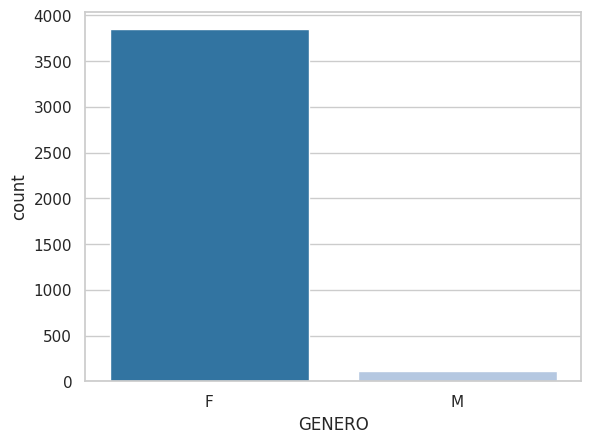

In [ ]:
sns.countplot(
    x=df.GENERO,
    palette='tab20'
)

### Estado civil pacientes
Categorica

In [ ]:
df.ESTADO_CIVIL.unique()

array(['SO', 'CA', 'UL', 'VI', 'SE'], dtype=object)

<Axes: xlabel='ESTADO_CIVIL', ylabel='count'>

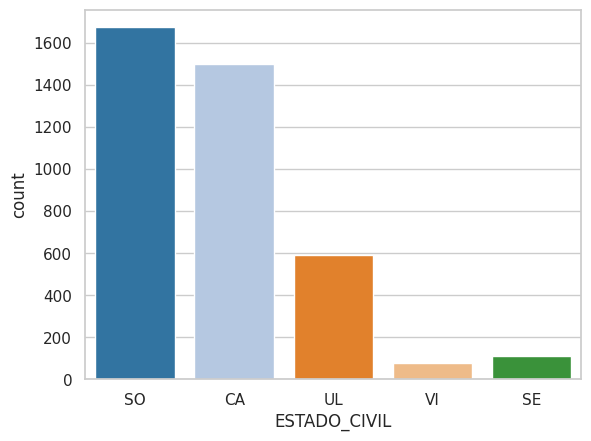

In [ ]:
sns.countplot(
    x=df.ESTADO_CIVIL,
    palette='tab20'
)

### No. Cancer diagnosticado por paciente
Categorica

In [ ]:
df.MULTI_CANCER.unique()

array([None, '1', '2'], dtype=object)

  Valor  Conteo
0  None    3618
1     1     317
2     2      20


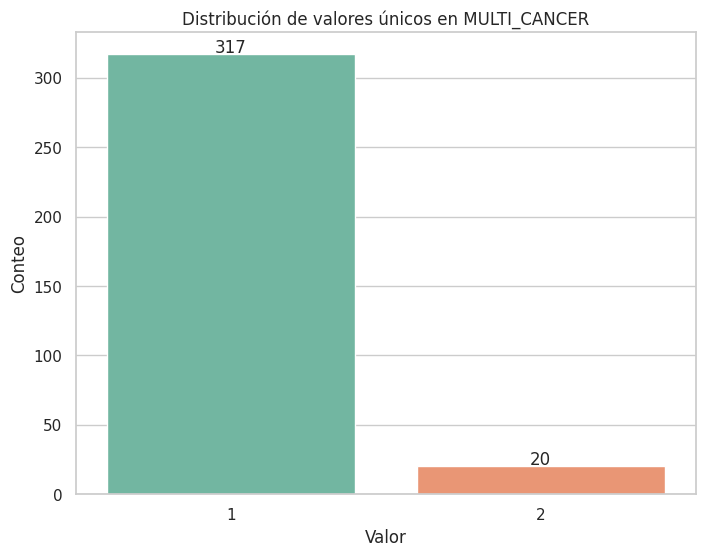

In [ ]:
df_Cancer = df
#Dados los nulos revisaremos estos valores
tabla_distribucion = df_Cancer['MULTI_CANCER'].value_counts(dropna=False).reset_index()
tabla_distribucion.columns = ['Valor', 'Conteo']

# Mostrar la tabla
print(tabla_distribucion)

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_Cancer, x='MULTI_CANCER', palette='Set2')
plt.title('Distribución de valores únicos en MULTI_CANCER')
plt.xlabel('Valor')
plt.ylabel('Conteo')
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 5),
                textcoords = 'offset points')

plt.show()

Dada la naturaleza de los datos y conocimiento de negocio, sera necesario realizar imputacion por un valor constante : 0

### Peso de Pacientes
Numerica

In [ ]:
#print(df.PESO.unique())
df.PESO=pd.to_numeric(df.PESO,errors='coerce')

df_peso = df
total_observaciones = df_peso.shape[0]
distribucion_peso = df_peso['PESO'].value_counts(dropna=False).reset_index()
distribucion_peso.columns = ['Valor', 'Conteo']
distribucion_peso['Porcentaje'] = (distribucion_peso['Conteo'] / total_observaciones)
na_values = distribucion_peso[distribucion_peso['Valor'].isna()]
print(f'Valores Nulos en PESO,\n{na_values}')

Valores Nulos en PESO,
   Valor  Conteo  Porcentaje
4    NaN     133    0.033628


In [ ]:
# Definir los límites de los grupos
grupos= [30, 50, 70, 90, 110, 130]

# Definir las etiquetas de los grupos
etiquetas = ['30-50', '50-70', '70-90', '90-110', '110-130']

# Crear una nueva columna en el DataFrame que contenga las categorías de los pesos
df_peso= pd.cut(df['PESO'], bins=grupos, labels=etiquetas, right=False)

# Contar cuántas observaciones hay en cada categoría
pesos_agrupados = df_peso.value_counts().sort_index()

print(pesos_agrupados)


PESO
30-50       237
50-70      2436
70-90      1033
90-110      104
110-130      10
Name: count, dtype: int64


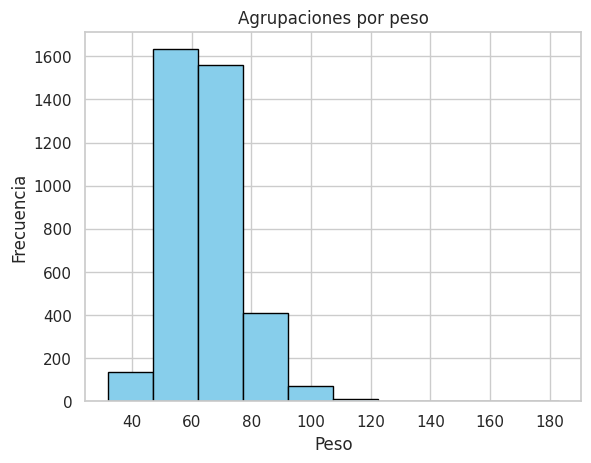

In [ ]:
df_peso = df['PESO']

# Crear el histograma
plt.hist(df_peso, color='skyblue', edgecolor='black')

# Etiquetas y título
plt.xlabel('Peso')
plt.ylabel('Frecuencia')
plt.title('Agrupaciones por peso')

# Mostrar el gráfico
plt.show()

### Talla de pacientes
Numerica

In [ ]:
df.TALLA.value_counts().sum() #pdte -> imputar

3822

In [ ]:
#df_talla = df[df['TALLA'] != '-']
#print(df.TALLA.unique())}
df_talla = df
df_talla['TALLA'] = pd.to_numeric(df['TALLA'], errors='coerce')

df_talla_ = df_talla
total_observaciones = df_talla_.shape[0]
distribucion_talla = df_talla_['TALLA'].value_counts(dropna=False).reset_index()
distribucion_talla.columns = ['Valor', 'Conteo']
distribucion_talla['Porcentaje'] = (distribucion_talla['Conteo'] / total_observaciones)
na_values = distribucion_talla[distribucion_talla['Valor'].isna()]
print(f'Valores Nulos en TALLA,\n{na_values}')

Valores Nulos en TALLA,
    Valor  Conteo  Porcentaje
12    NaN     133    0.033628


In [ ]:
df_talla = df[df['TALLA'] != '-']
df_talla['TALLA'] = pd.to_numeric(df_talla['TALLA'], errors='coerce')

# Definir los límites de los grupos
grupos = [130, 150, 170, 190]

# Definir las etiquetas de los grupos
etiquetas = ['130-150', '150-170', '170-190']

# Crear una nueva columna en el DataFrame que contenga las categorías de las tallas
df_talla = pd.cut(df_talla['TALLA'], bins=grupos, labels=etiquetas)#, right=False)

# Contar cuántas observaciones hay en cada categoría
talla_agrupados = df_talla.value_counts().sort_index()

print(talla_agrupados)

TALLA
130-150     808
150-170    2939
170-190      74
Name: count, dtype: int64


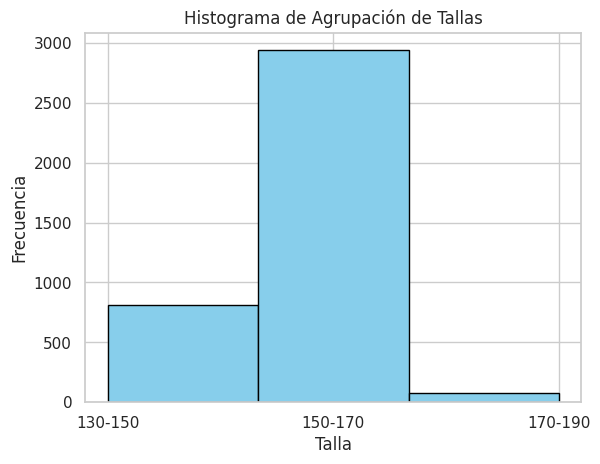

In [ ]:
plt.hist(talla_agrupados.index, bins=len(talla_agrupados), weights=talla_agrupados.values, color='skyblue', edgecolor='black')

# Etiquetas y título
plt.xlabel('Talla')
plt.ylabel('Frecuencia')
plt.title('Histograma de Agrupación de Tallas')

# Mostrar el gráfico
plt.show()

Para poder determinar una estrategia adecuada de imputacion (simple imputer o knn imputer) revisemos los valores atipicos y la escala de las caracteristicas

#### Analisis de Outliers de PESO y TALLA

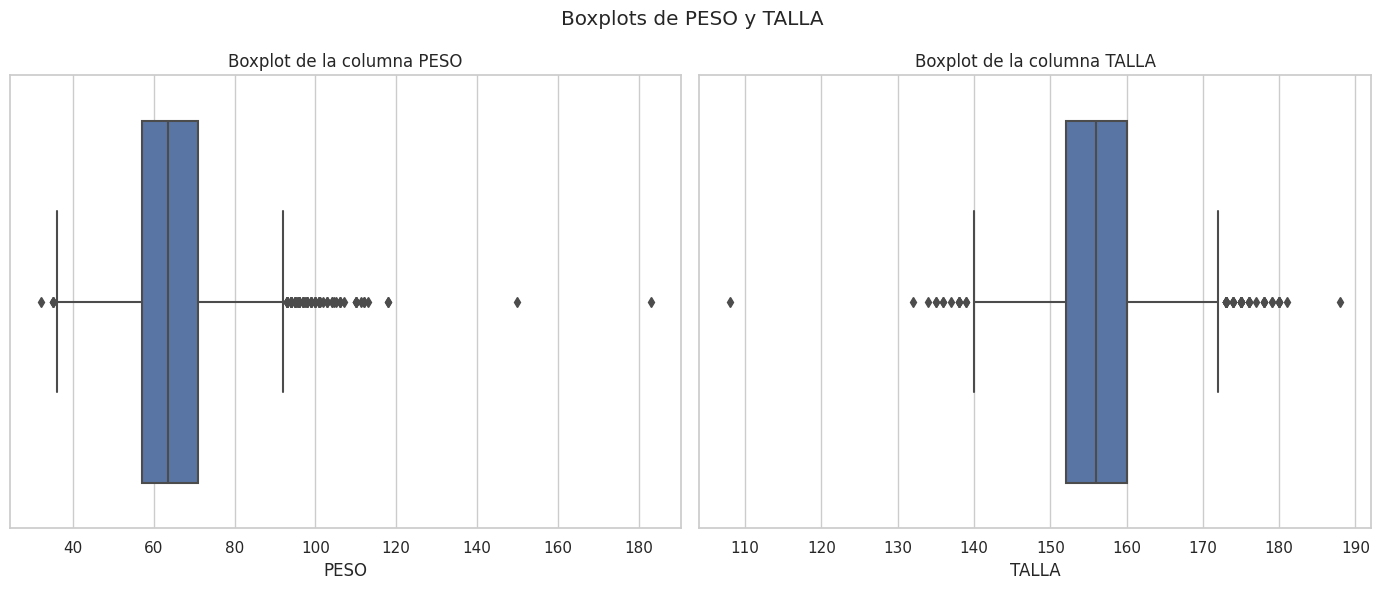

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='PESO')
plt.title('Boxplot de la columna PESO')
plt.xlabel('PESO')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='TALLA')
plt.title('Boxplot de la columna TALLA')
plt.xlabel('TALLA')
plt.suptitle('Boxplots de PESO y TALLA')
plt.tight_layout()

plt.show()

Antes de realizar imputacion tenemos que hacer tratamiento de atipicos, entendamos cuales son los atipicos.

In [ ]:
#Tukey's method
def tukeys_method(df, variable):
    #Takes two parameters: dataframe & variable of interest as string
    q1 = df[variable].quantile(0.25)
    q3 = df[variable].quantile(0.75)
    iqr = q3-q1
    inner_fence = 1.5*iqr
    outer_fence = 3*iqr

    #inner fence lower and upper end
    inner_fence_le = q1-inner_fence
    inner_fence_ue = q3+inner_fence

    #outer fence lower and upper end
    outer_fence_le = q1-outer_fence
    outer_fence_ue = q3+outer_fence

    outliers_prob = []
    outliers_poss = []
    for index, x in enumerate(df[variable]):
        if x <= outer_fence_le or x >= outer_fence_ue:
            outliers_prob.append(index)
    for index, x in enumerate(df[variable]):
        if x <= inner_fence_le or x >= inner_fence_ue:
            outliers_poss.append(index)
    return outliers_prob, outliers_poss

In [ ]:
probable_outliers_peso, possible_outliers_peso = tukeys_method(df, "PESO")
probable_outliers_talla, possible_outliers_talla = tukeys_method(df, "TALLA")
print(f'indices de outliers de PESO: {probable_outliers_peso}\nindices de outliers de TALLA: {probable_outliers_talla}')

indices de outliers de PESO: [624, 874, 1479, 1649, 2481]
indices de outliers de TALLA: [874, 1521]


[REFERENCIA : detección y tratamiento de outliers en Python](https://towardsdatascience.com/detecting-and-treating-outliers-in-python-part-1-4ece5098b755)


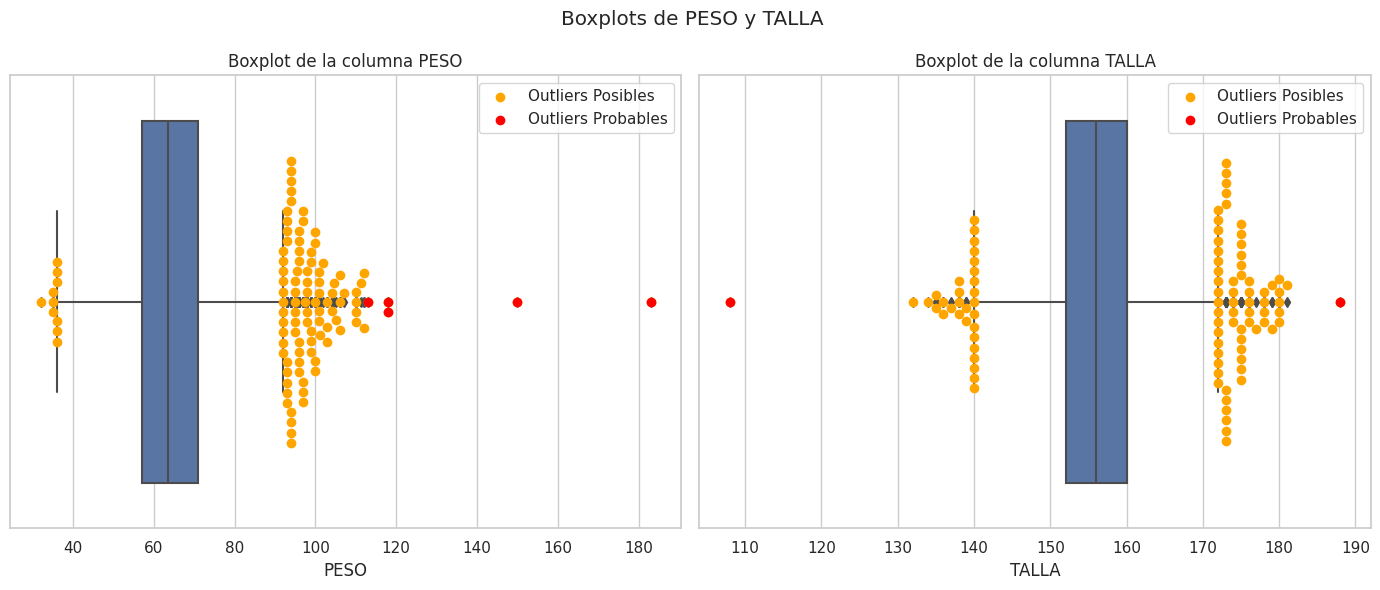

In [ ]:
# Generate boxplots
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='PESO')
plt.title('Boxplot de la columna PESO')
plt.xlabel('PESO')

# Mark outliers on the PESO boxplot
outliers_prob, outliers_poss = tukeys_method(df, 'PESO')
sns.swarmplot(data=df.iloc[outliers_poss], x='PESO', color='orange', marker='o', size=7, label='Outliers Posibles')
sns.swarmplot(data=df.iloc[outliers_prob], x='PESO', color='red', marker='o', size=7, label='Outliers Probables')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='TALLA')
plt.title('Boxplot de la columna TALLA')
plt.xlabel('TALLA')

# Mark outliers on the TALLA boxplot
outliers_prob, outliers_poss = tukeys_method(df, 'TALLA')
sns.swarmplot(data=df.iloc[outliers_poss], x='TALLA', color='orange', marker='o', size=7, label='Outliers Posibles')
sns.swarmplot(data=df.iloc[outliers_prob], x='TALLA', color='red', marker='o', size=7, label='Outliers Probables')
plt.legend()

plt.suptitle('Boxplots de PESO y TALLA')
plt.tight_layout()

plt.show()


Estos registros podrian ser candidatos para eliminacion o imputacion en las columnas de TALLA y PESO

### Pacientes en Urgencias
Categorica

In [ ]:
df.URGENCIAS.unique()

array([0., 2., 3., 1., 9., 4.])

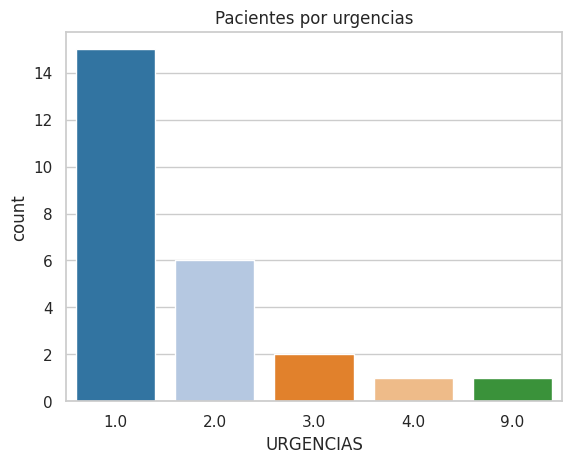

In [ ]:
filtered_df = df[df['URGENCIAS'] > 0]
sns.countplot(x=filtered_df['URGENCIAS'], palette='tab20')
plt.title('Pacientes por urgencias')
plt.show()

### Antecendentes
Categoricas

In [ ]:
cancer_mama_familiar = pd.crosstab(index=df['CANCER_MAMA_FAMILIAR'],columns='CancerMamaFamiliar')
cancer_otro_sitio  = pd.crosstab(index=df['CANCER_OTRO_SITIO'],columns='CancerOtroSitio')
cancer_otro_sitio_familiar = pd.crosstab(index=df['CANCER_OTRO_SITIO_FAMILIAR'],columns='CancerOtroSitioFamiliar')
cerebral_familiar = pd.crosstab(index=df['CEREBRAL_FAMILIAR'],columns='CerebralFamiliar')

# Concatenar las tablas una al lado de la otra
result = pd.concat([cancer_mama_familiar, cancer_otro_sitio, cancer_otro_sitio_familiar, cerebral_familiar], axis=1)

# Mostrar el resultado
result

col_0,CancerMamaFamiliar,CancerOtroSitio,CancerOtroSitioFamiliar,CerebralFamiliar
0,3622,3159,3225,3882
1,333,796,730,73


(3955, 4)


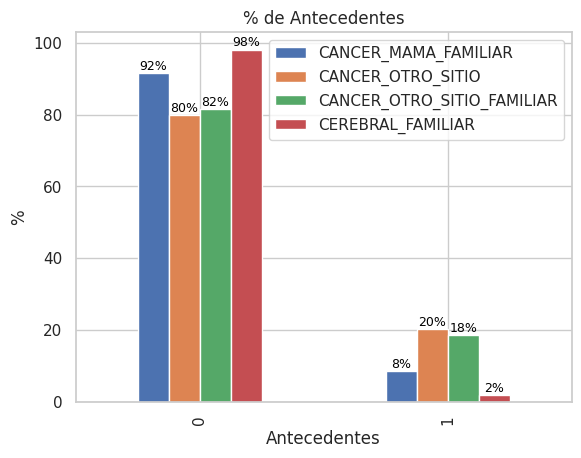

In [ ]:
df_cancer = df[['CANCER_MAMA_FAMILIAR','CANCER_OTRO_SITIO','CANCER_OTRO_SITIO_FAMILIAR','CEREBRAL_FAMILIAR']]
print(df_cancer.shape)
porcentaje = df_cancer.apply(lambda x: x.value_counts(normalize=True) * 100)
ax = porcentaje.plot(kind='bar')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xlabel('Antecedentes')
plt.ylabel('%')
plt.title('% de Antecedentes')

plt.show()

### Presion Arterial
Numerica

In [ ]:
#Presión Sistolica y diastolica (Contrae y relaja)
df.TSISTOLICA.unique()
#df.TDIASTOLICA.unique()

array([112., 120., 110., 117., 102., 114.,  nan, 130., 124., 122., 135.,
       134., 115., 128., 100., 126., 140., 118., 146., 105., 125., 133.,
       160., 116., 137., 142., 129., 127., 121., 119., 106., 138., 136.,
       139., 104.,  90., 180., 150., 103., 111., 157., 109., 155., 152.,
       176., 132., 144., 192., 108., 170., 143., 145., 167., 181., 200.,
       175., 164., 161., 123., 131.,  94., 151., 209., 162., 156., 101.,
        95., 141.,  99., 185., 168.,  83., 107., 148.,  91., 113., 171.,
        80.,  98., 166., 153., 202., 154., 165., 158., 147., 173., 218.])

In [ ]:
#print(df.TALLA.unique())}
df_sistolica = df
df_sistolica['TSISTOLICA'] = pd.to_numeric(df_sistolica['TSISTOLICA'], errors='coerce')

total_observaciones = df_sistolica.shape[0]
distribucion_tS = df_sistolica['TSISTOLICA'].value_counts(dropna=False).reset_index()
distribucion_tS.columns = ['Valor', 'Conteo']
distribucion_tS['Porcentaje'] = (distribucion_tS['Conteo'] / total_observaciones)
na_values_tS = distribucion_tS[distribucion_tS['Valor'].isna()]
print(f'Valores Nulos de TSISTOLICA:\n{na_values_tS}')

Valores Nulos de TSISTOLICA:
   Valor  Conteo  Porcentaje
4    NaN     140    0.035398


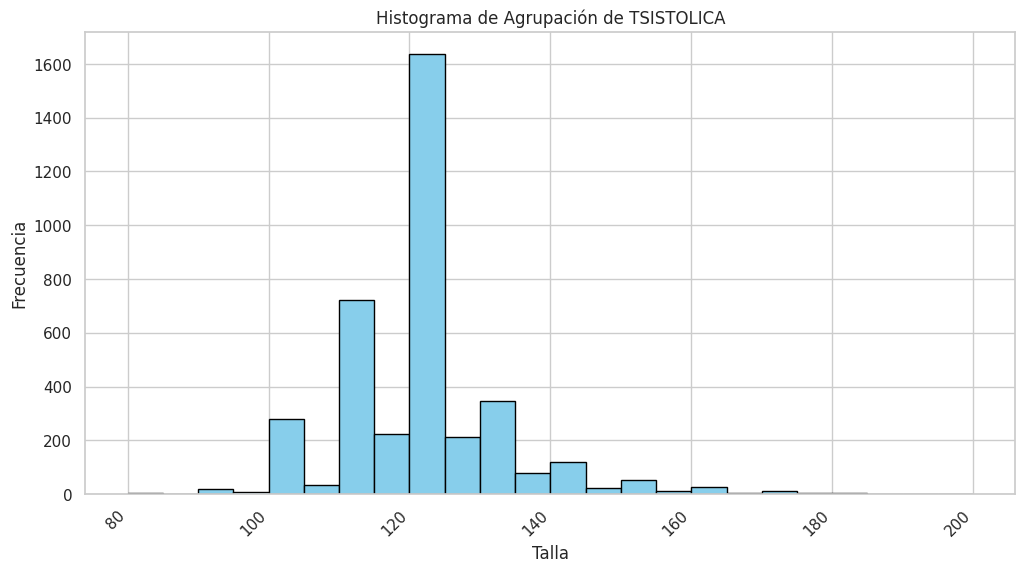

In [ ]:
# Definir los límites de los grupos
grupos = [80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200]

# Definir las etiquetas de los grupos
etiquetas = ['80-85', '85-90', '90-95', '95-100', '100-105',
             '105-110', '110-115', '115-120', '120-125', '125-130',
             '130-135', '135-140', '140-145', '145-150', '150-155',
             '155-160', '160-165', '165-170', '170-175', '175-180',
             '180-185', '185-190', '190-195', '195-200']

# Crear una nueva columna en el DataFrame que contenga las categorías de las tallas
df_sistolica['TSISTOLICA_CATEGORIA'] = pd.cut(df_sistolica['TSISTOLICA'], bins=grupos, labels=etiquetas)

# Contar cuántas observaciones hay en cada categoría
tS_agrupados = df_sistolica['TSISTOLICA_CATEGORIA'].value_counts().sort_index()

# Configurar el tamaño de la figura para que sea más alargada
plt.figure(figsize=(12, 6))

# Generar el histograma
plt.hist(x=df_sistolica['TSISTOLICA'], bins=grupos, color='skyblue', edgecolor='black')

# Rotar las etiquetas del eje x para que sean legibles
plt.xticks(rotation=45, ha='right')

# Etiquetas y título
plt.xlabel('Talla')
plt.ylabel('Frecuencia')
plt.title('Histograma de Agrupación de TSISTOLICA')

# Mostrar el gráfico
plt.show()

In [ ]:
df.TDIASTOLICA.unique()

array([ 70.,  80.,  65.,  63.,  84.,  60.,  75.,  nan,  90.,  82.,  83.,
        76.,  58.,  62.,  72.,  85.,  68.,  92., 100.,  78.,  88.,  64.,
        67.,  91.,  66.,  94.,  98.,  79.,  87.,  53.,  74.,  86.,  95.,
        55.,  51.,  77.,  69.,  41.,  96.,  81.,  89.,  97.,  71.,  56.,
        73., 120.,  61.,  47.,  59.,  99., 114.,  45.,  50., 104.,  54.,
       106., 110.])

In [ ]:
df_tdiastolica = df
df_tdiastolica['TDIASTOLICA'] = pd.to_numeric(df_tdiastolica['TDIASTOLICA'], errors='coerce')

total_observaciones = df_tdiastolica.shape[0]
distribucion_tD = df_tdiastolica['TDIASTOLICA'].value_counts(dropna=False).reset_index()
distribucion_tD.columns = ['Valor', 'Conteo']
distribucion_tD['Porcentaje'] = (distribucion_tD['Conteo'] / total_observaciones)
na_values_tD = distribucion_tD[distribucion_tD['Valor'].isna()]
print(f'Valores Nulos de TDIASTOLICA:\n{na_values_tD}')

Valores Nulos de TDIASTOLICA:
   Valor  Conteo  Porcentaje
3    NaN     140    0.035398


TDIASTOLICA_CATEGORIA
40-45         3
45-50         6
50-55         8
55-60       381
60-65       104
65-70      1330
70-75       232
75-80      1428
80-85       131
85-90       129
90-95        18
95-100       39
100-105       1
105-110       3
Name: count, dtype: int64


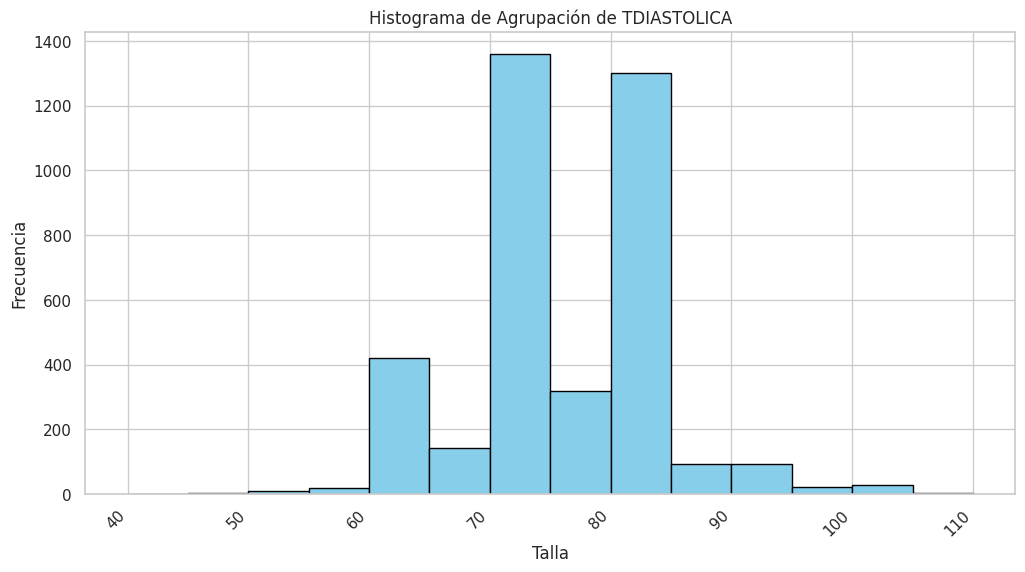

In [ ]:
# Definir los límites de los grupos
grupos = [40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110]

# Definir las etiquetas de los grupos
etiquetas = ['40-45', '45-50', '50-55', '55-60', '60-65',
             '65-70', '70-75', '75-80', '80-85', '85-90',
             '90-95', '95-100', '100-105', '105-110']

# Crear una nueva columna en el DataFrame que contenga las categorías de las tallas
df_tdiastolica['TDIASTOLICA_CATEGORIA'] = pd.cut(df_tdiastolica['TDIASTOLICA'], bins=grupos, labels=etiquetas)#, right=False)

# Contar cuántas observaciones hay en cada categoría
tD_agrupados = df_tdiastolica['TDIASTOLICA_CATEGORIA'].value_counts().sort_index()

print(tD_agrupados)
# Configurar el tamaño de la figura para que sea más alargada
plt.figure(figsize=(12, 6))
# Generar el histograma
plt.hist(x=df_sistolica['TDIASTOLICA'], bins=grupos, color='skyblue', edgecolor='black')
# Rotar las etiquetas del eje x para que sean legibles
plt.xticks(rotation=45, ha='right')

# Etiquetas y título
plt.xlabel('Talla')
plt.ylabel('Frecuencia')
plt.title('Histograma de Agrupación de TDIASTOLICA')

# Mostrar el gráfico
plt.show()

In [ ]:
print(f'Valores Nulos de TDIASTOLICA:\n{na_values_tD}\nValores Nulos de TSISTOLICA:\n{na_values_tS}')

Valores Nulos de TDIASTOLICA:
   Valor  Conteo  Porcentaje
3    NaN     140    0.035398
Valores Nulos de TSISTOLICA:
   Valor  Conteo  Porcentaje
4    NaN     140    0.035398


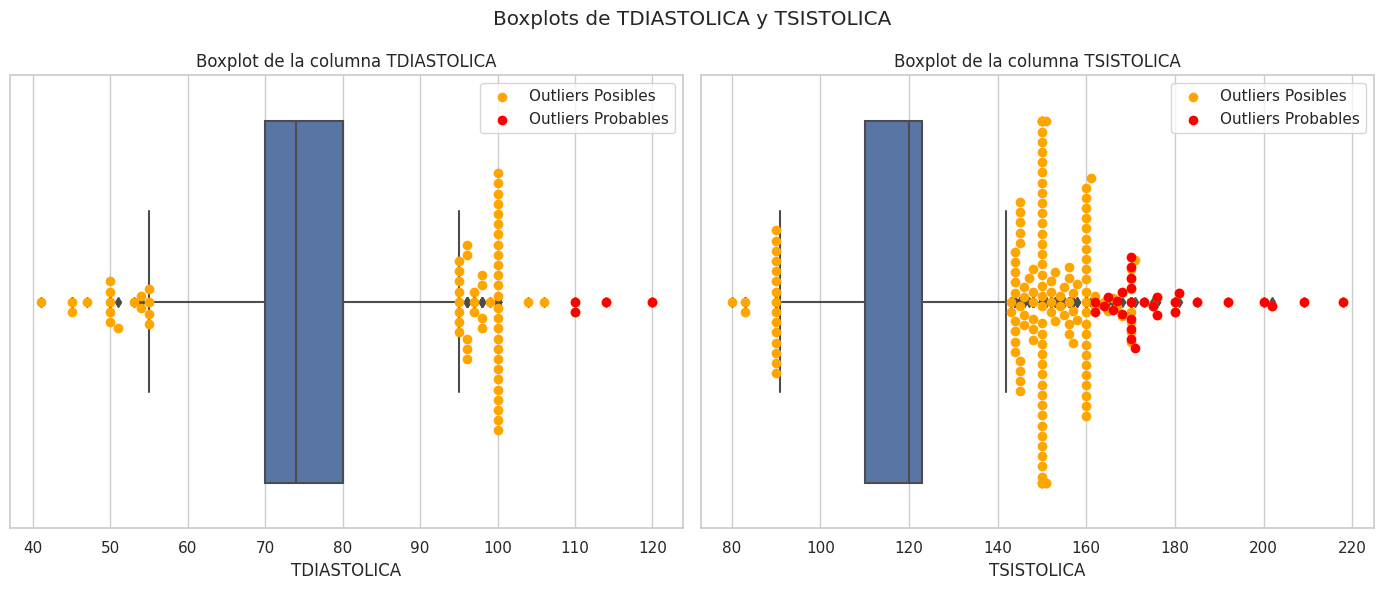

In [ ]:
# Generate boxplots
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='TDIASTOLICA')
plt.title('Boxplot de la columna TDIASTOLICA')
plt.xlabel('TDIASTOLICA')

# Mark outliers on the PESO boxplot
outliers_prob, outliers_poss = tukeys_method(df, 'TDIASTOLICA')
sns.swarmplot(data=df.iloc[outliers_poss], x='TDIASTOLICA', color='orange', marker='o', size=7, label='Outliers Posibles')
sns.swarmplot(data=df.iloc[outliers_prob], x='TDIASTOLICA', color='red', marker='o', size=7, label='Outliers Probables')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='TSISTOLICA')
plt.title('Boxplot de la columna TSISTOLICA')
plt.xlabel('TSISTOLICA')

# Mark outliers on the TALLA boxplot
outliers_prob, outliers_poss = tukeys_method(df, 'TSISTOLICA')
sns.swarmplot(data=df.iloc[outliers_poss], x='TSISTOLICA', color='orange', marker='o', size=7, label='Outliers Posibles')
sns.swarmplot(data=df.iloc[outliers_prob], x='TSISTOLICA', color='red', marker='o', size=7, label='Outliers Probables')
plt.legend()

plt.suptitle('Boxplots de TDIASTOLICA y TSISTOLICA')
plt.tight_layout()

plt.show()

### Riesgos
categorica

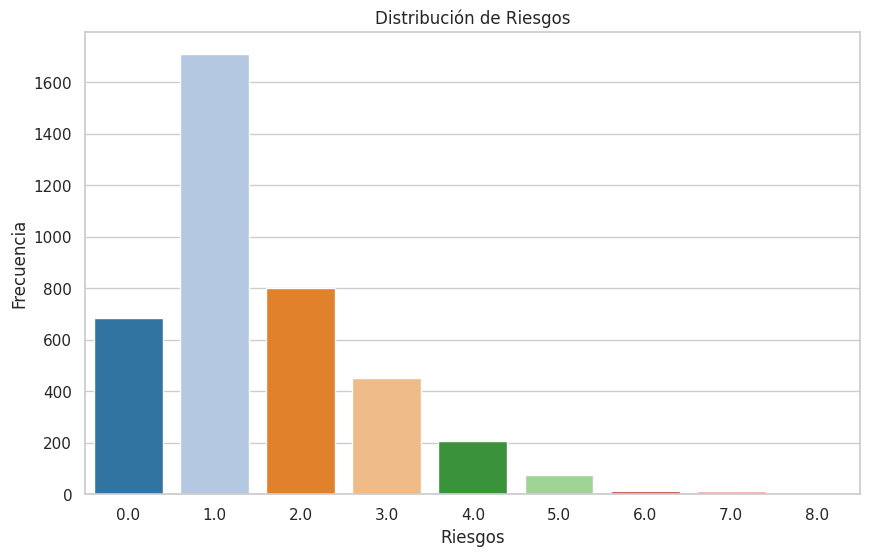

In [ ]:
riesgos_conteo=df.RIESGOS.value_counts()
# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='RIESGOS', palette='tab20')

# Añadir etiquetas y título
plt.xlabel('Riesgos')
plt.ylabel('Frecuencia')
plt.title('Distribución de Riesgos')

# Mostrar el gráfico
plt.show()

In [ ]:
# con esto podemos ver que
# tenemos mayor cantidad de pacientes con 1 riesgo de cancer

### Edad de pacientes

In [ ]:
from datetime import datetime
today = datetime.now()
df['Edad'] = today.year - df['FECHA_NACIMIENTO'].dt.year

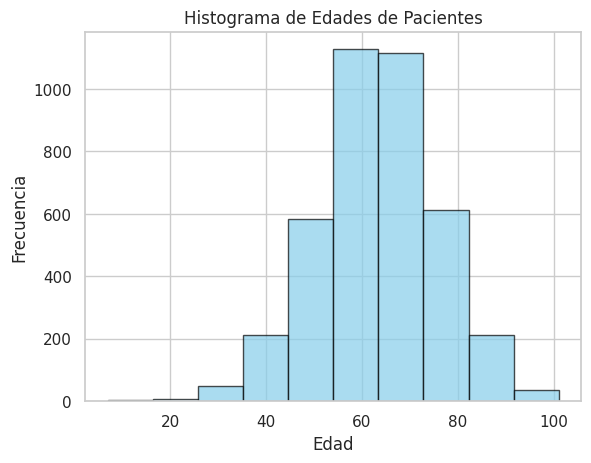

In [ ]:
# Graficar un histograma de edades de las mujeres
plt.hist(df['Edad'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Histograma de Edades de Pacientes')
plt.grid(True)
plt.show()

### Complicaciones

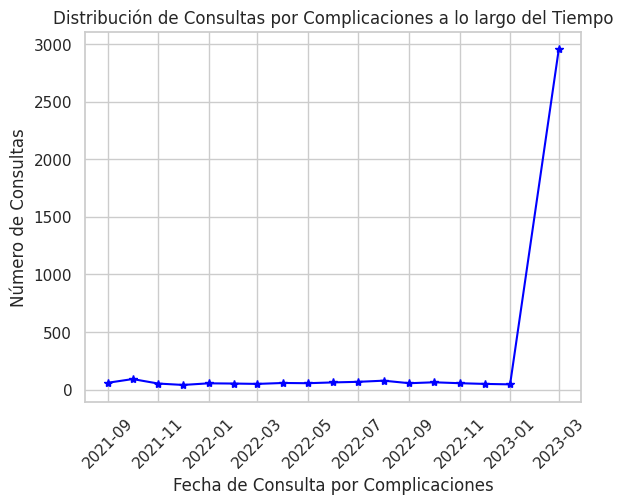

In [ ]:
# Contar el número de consultas por complicaciones por cada día
consulta_por_dia = df['Fecha_cero'].value_counts().sort_index()

# Graficar un diagrama de líneas de la distribución de fechas de consulta por complicaciones
plt.plot(consulta_por_dia.index, consulta_por_dia.values, marker='*', color='blue')
plt.xlabel('Fecha de Consulta por Complicaciones')
plt.ylabel('Número de Consultas')
plt.title('Distribución de Consultas por Complicaciones a lo largo del Tiempo')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Analisis de Variable Objetivo
### Objetivo
Caterogica


Target
0.0    3508
1.0     447
Name: count, dtype: int64


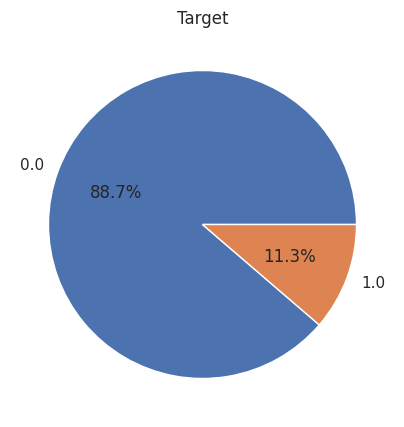

In [ ]:
df.Target.value_counts()
target_counts = df['Target'].value_counts()
print(target_counts)
porcentajes = target_counts / len(df) * 100
plt.figure(figsize=(5, 5))
plt.pie(porcentajes, labels=porcentajes.index, autopct='%1.1f%%')
plt.title('Target')
plt.show()

## Valores Nulos

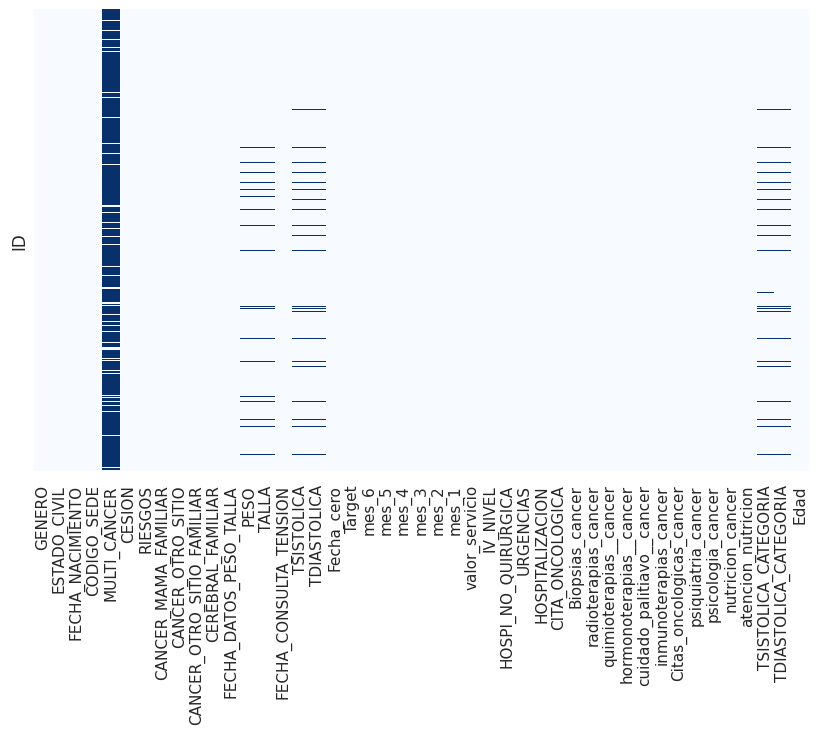

In [ ]:
# Mapa de calor de datos para revisar nulos
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap="Blues")
plt.show()

In [ ]:
porcetaje_de_nulidad = (
    df.isnull()
    .apply(lambda s: s.value_counts(True)).T
)

porcetaje_de_nulidad.columns = ['not_null', 'null']
variables_muy_nulas = porcetaje_de_nulidad.query('null > 0.7').index
nnulos = porcetaje_de_nulidad.dropna(subset=['null'])
nnulos

,not_null,null
MULTI_CANCER,0.085209,0.914791
PESO,0.966372,0.033628
TALLA,0.966372,0.033628
TSISTOLICA,0.964602,0.035398
TDIASTOLICA,0.964602,0.035398
TSISTOLICA_CATEGORIA,0.963590,0.036410
TDIASTOLICA_CATEGORIA,0.964096,0.035904


In [ ]:
variables_muy_nulas

Index(['MULTI_CANCER'], dtype='object')

## Histograma Resumen

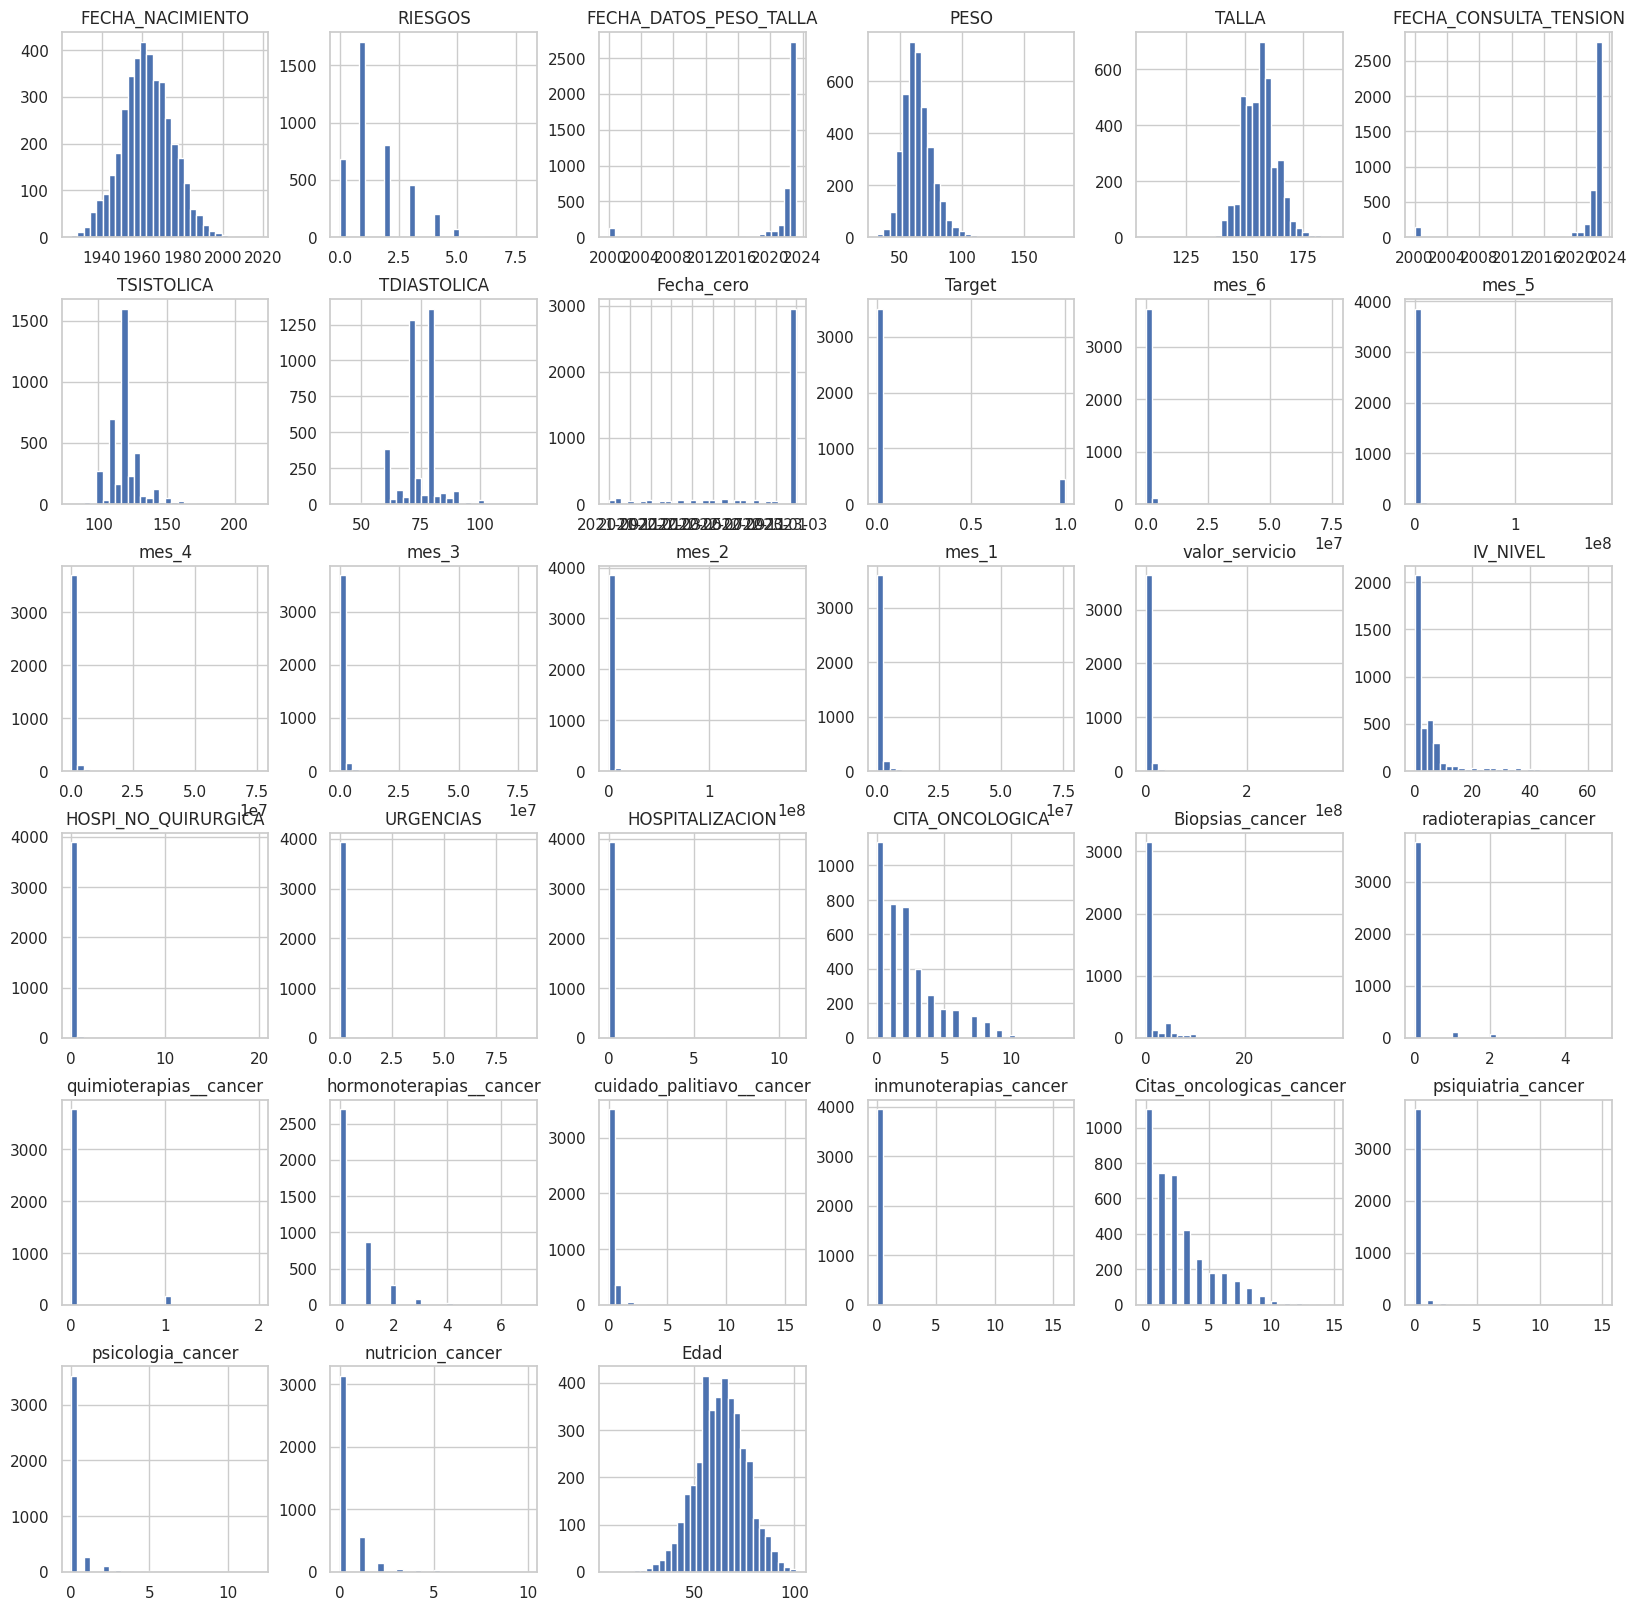

In [ ]:
df.hist(bins = 30, figsize = (20, 20), color = 'b');

## Matriz de Correlacion

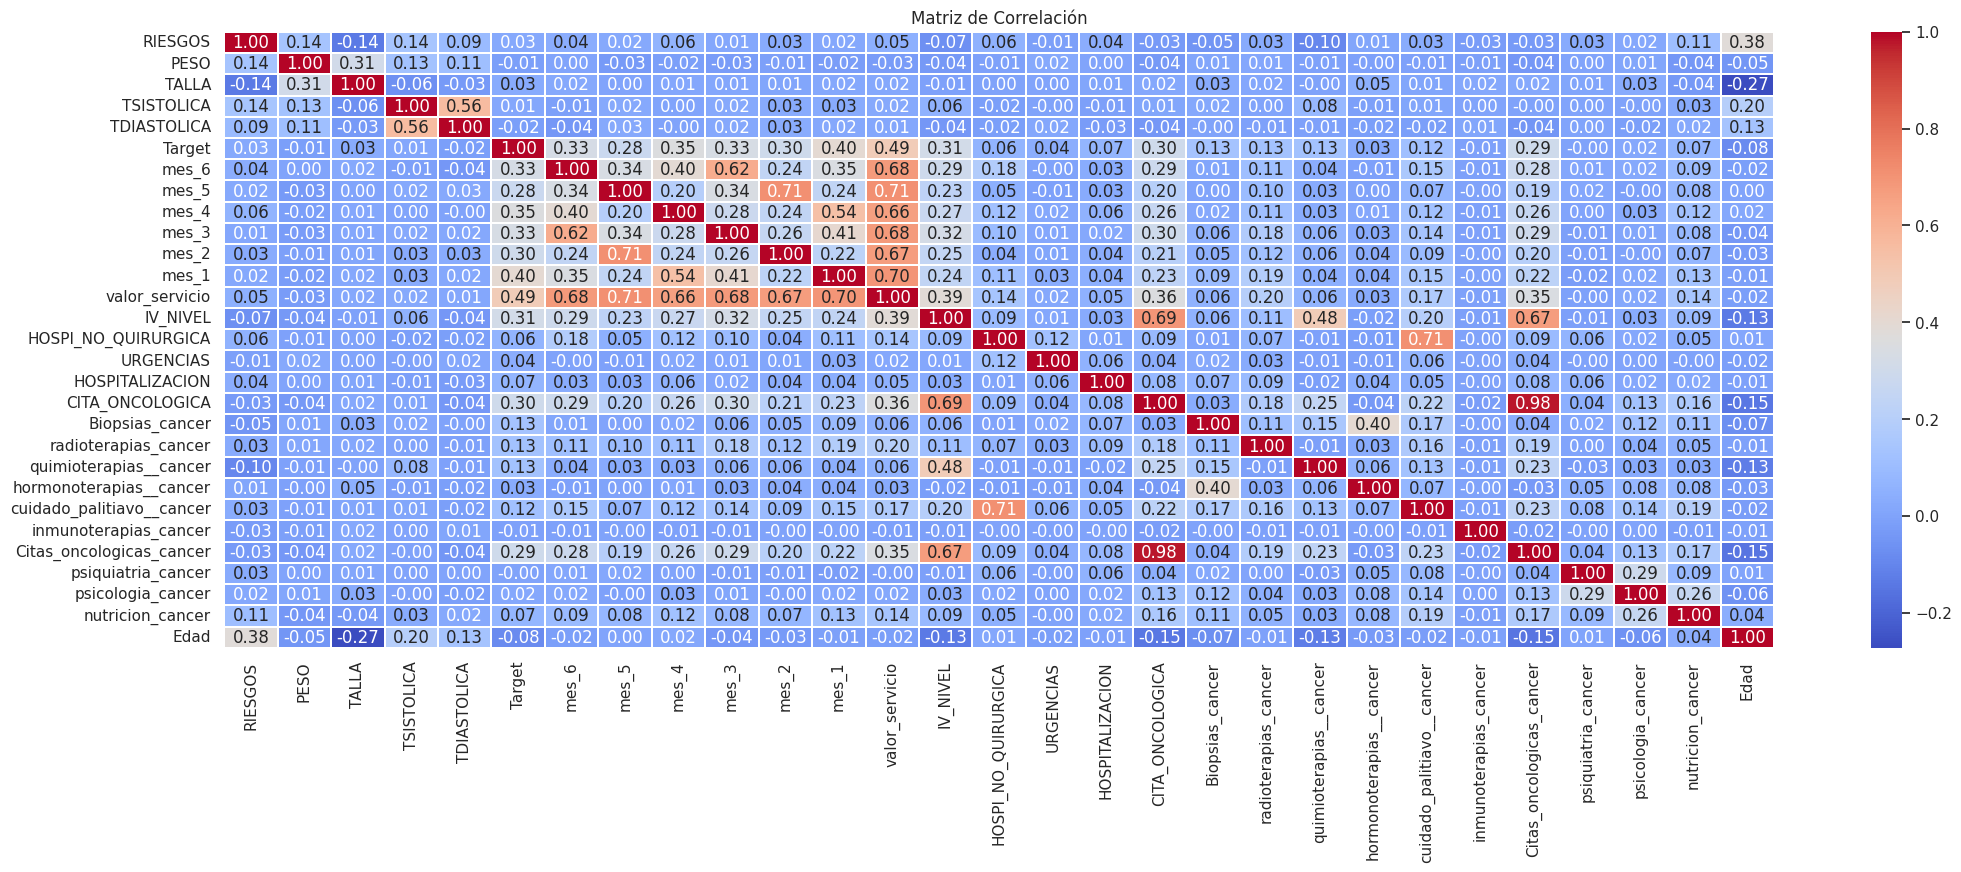

In [ ]:
# Imputar los valores '-'
df.replace('-', np.nan, inplace=True)

# Convertir las columnas numéricas a tipo de datos numéricos
numeric_columns = df.select_dtypes(include=[np.number]).columns
df[numeric_columns] = df[numeric_columns].astype(float)

# Filtrar solo los datos numéricos
numeric_df = df[numeric_columns]

# Calcular la matriz de correlación
correlation_matrix = numeric_df.corr()
# Visualizar la matriz de correlación como un mapa de calor
plt.figure(figsize=(25, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.2)
plt.title('Matriz de Correlación')
plt.show()

## Baseline

In [ ]:
df.Target.value_counts()

Target
0.0    3508
1.0     447
Name: count, dtype: int64

In [ ]:
#antes de iniciar con la preparacion de datos, revisemos el baseline
porcent = df['Target'][df['Target'] == 0.0].count()/df.Target.shape[0]*100
print(f'{round(porcent,2)} %')

88.7 %


In [ ]:
# Ratificamos los cambios que debemos realizar con respecto a las características
# normalized-losses debería ser númerico y no categórico
# number-of-doors debería ser numérico
# num-of-cylinders debería ser numérico
# bore (diámetro del motor) debería ser numérico
# stroke debe ser numérico
# horse-power debe ser numérico
# peak-rpm debe ser numérico
# price debe ser numérico

#GENERO                                debe ser categorica
#ESTADO_CIVIL                          debe ser categorica
#CODIGO_SEDE                           debe ser categorica
#MULTI_CANCER                          debe ser categorica
#CESION                                debe ser categorica
#RIESGOS                               debe ser categorica
#CANCER_MAMA_FAMILIAR                  debe ser categorica
#CANCER_OTRO_SITIO                     debe ser categorica
#CANCER_OTRO_SITIO_FAMILIAR            debe ser categorica
#CEREBRAL_FAMILIAR                     debe ser categorica
#Fecha_cero                            ELIMINAR (por "negocio")
#atencion_nutricion                    debe ser categorica

#df.select_dtypes(exclude=['float']).columns
df.dtypes

GENERO                                object
ESTADO_CIVIL                          object
FECHA_NACIMIENTO              datetime64[us]
CODIGO_SEDE                           object
MULTI_CANCER                          object
CESION                                object
RIESGOS                              float64
CANCER_MAMA_FAMILIAR                  object
CANCER_OTRO_SITIO                     object
CANCER_OTRO_SITIO_FAMILIAR            object
CEREBRAL_FAMILIAR                     object
FECHA_DATOS_PESO_TALLA        datetime64[us]
PESO                                 float64
TALLA                                float64
FECHA_CONSULTA_TENSION        datetime64[us]
TSISTOLICA                           float64
TDIASTOLICA                          float64
Fecha_cero                    datetime64[us]
Target                               float64
mes_6                                float64
mes_5                                float64
mes_4                                float64
mes_3     

In [ ]:
for var in df.select_dtypes(include=['object']).columns:
    cantidad = df[df[var] == '-'][var].count()
    print(f"Existen {cantidad} valores en {var} con el valor -")

for var in df.columns:
    cantidad_nan = df[var].isna().sum()  # Contar los valores NaN en la columna
    cantidad_no_cero = (df[var] != 0).sum()  # Contar los valores no cero en la columna

    if cantidad_nan > 0 and cantidad_no_cero > 0:
        print(f"Existen {cantidad_nan} valores NaN en {var}")


Existen 0 valores en GENERO con el valor -
Existen 0 valores en ESTADO_CIVIL con el valor -
Existen 0 valores en CODIGO_SEDE con el valor -
Existen 0 valores en MULTI_CANCER con el valor -
Existen 0 valores en CESION con el valor -
Existen 0 valores en CANCER_MAMA_FAMILIAR con el valor -
Existen 0 valores en CANCER_OTRO_SITIO con el valor -
Existen 0 valores en CANCER_OTRO_SITIO_FAMILIAR con el valor -
Existen 0 valores en CEREBRAL_FAMILIAR con el valor -
Existen 0 valores en atencion_nutricion con el valor -
Existen 3618 valores NaN en MULTI_CANCER
Existen 133 valores NaN en PESO
Existen 133 valores NaN en TALLA
Existen 140 valores NaN en TSISTOLICA
Existen 140 valores NaN en TDIASTOLICA
Existen 144 valores NaN en TSISTOLICA_CATEGORIA
Existen 142 valores NaN en TDIASTOLICA_CATEGORIA


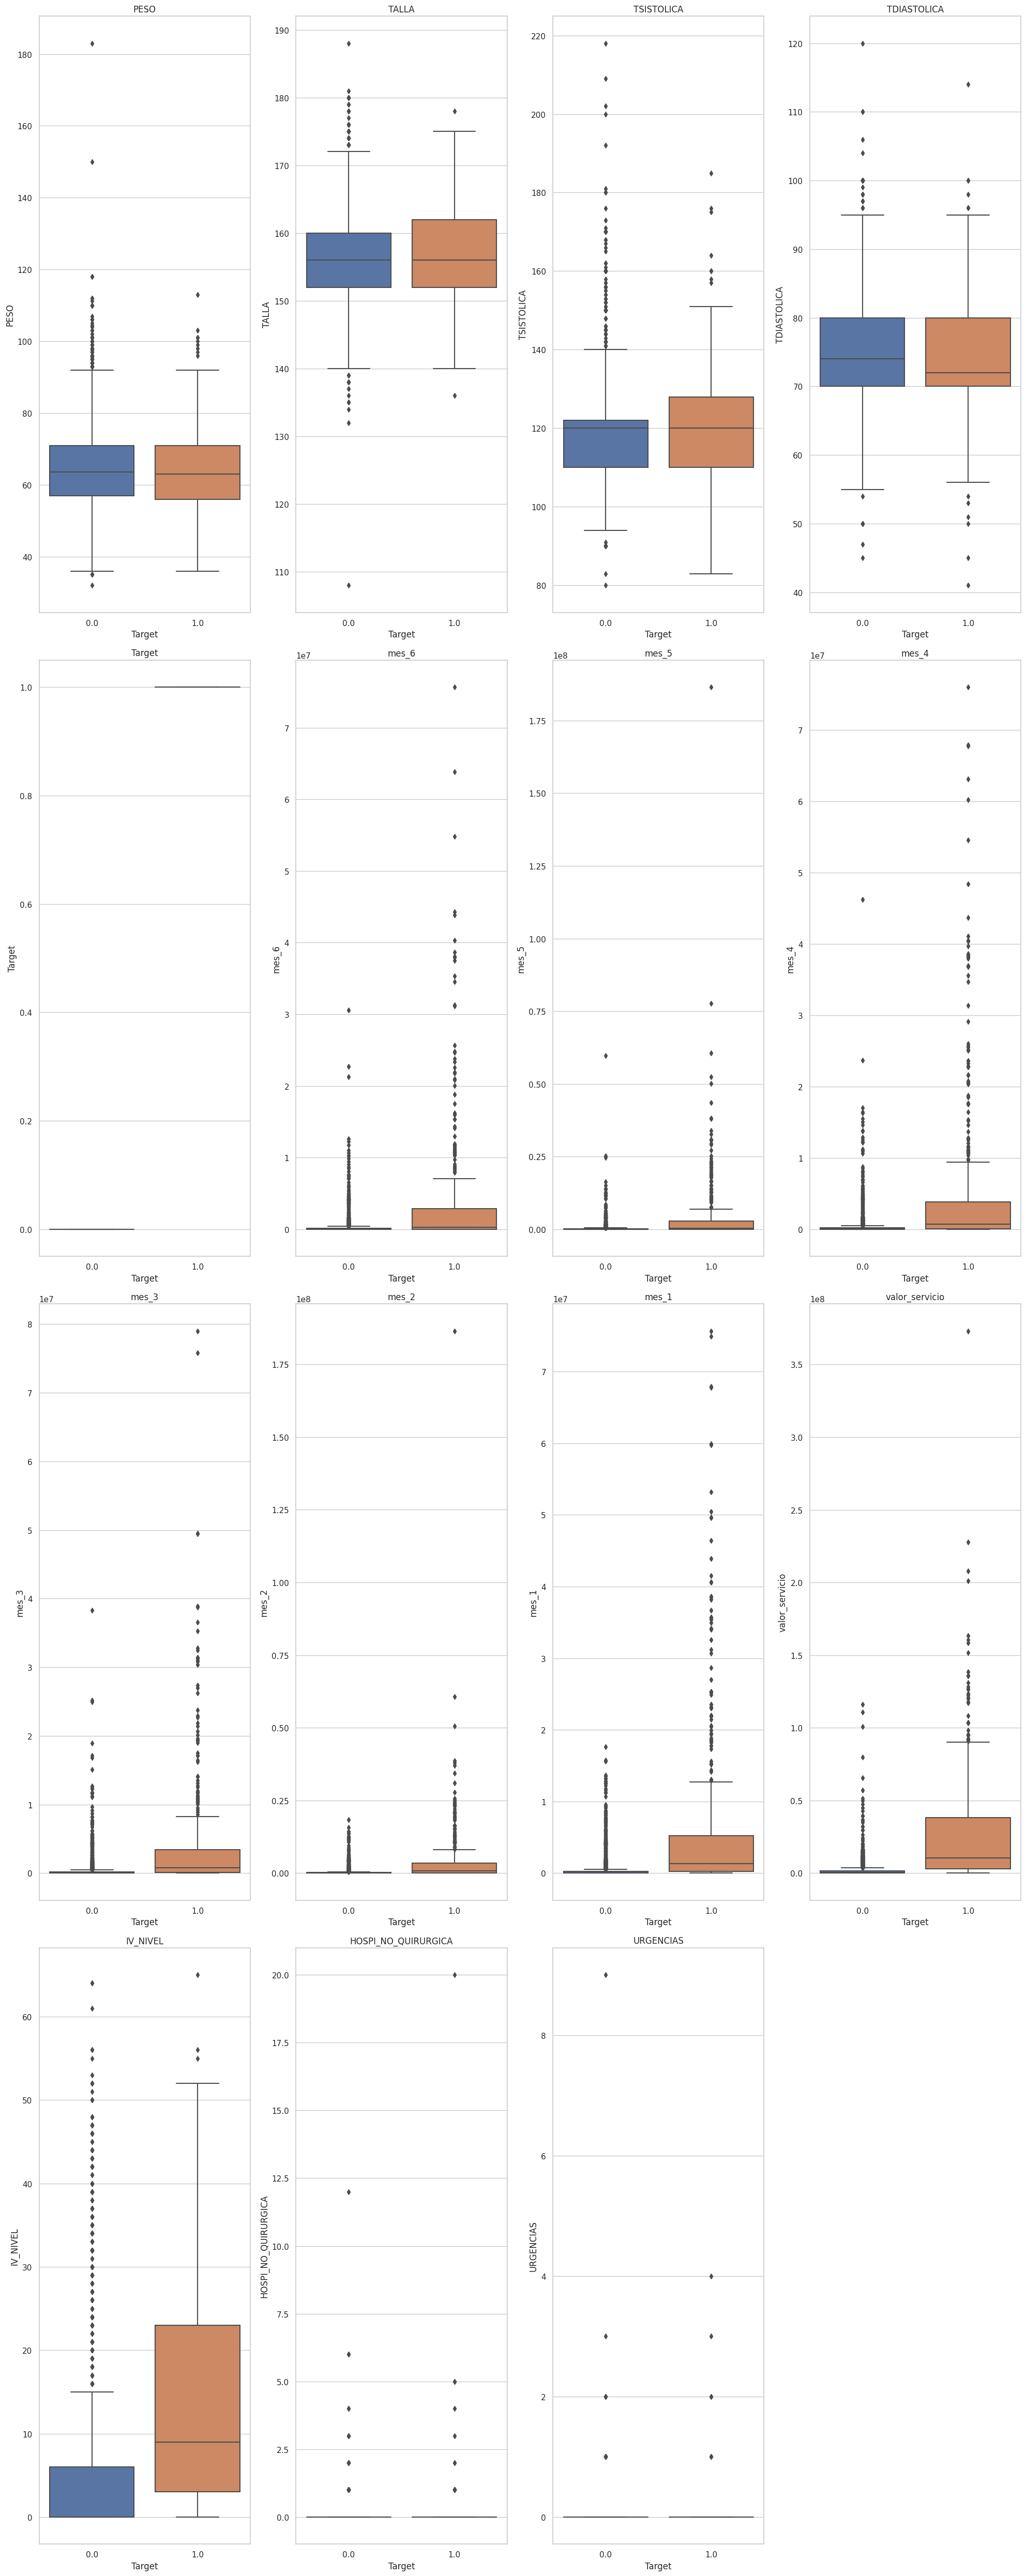

In [ ]:
# Mediante el diagrama de cajas y bigotes vemos un resumen visual de la distribución de cada
# uno de las variables independientes con respecto a la dependiente
# Podemos observar la distribución de los distintos grupos

fig = plt.figure(figsize=(20,50))
i=1

for var_num in df.select_dtypes(include=['int64','float64']).columns[1:16]:
    ax = fig.add_subplot(4, 4, i)
    sns.boxplot(x=df.Target, y=var_num, data=df)
    plt.title(var_num)
    i+=1
fig.tight_layout()

In [ ]:
#upper_bounds={}
#lower_bounds={}
#for col in df.select_dtypes(include=['int64','float64']).columns[1:26]:
#    values=df[col]
#    upper_bounds[col]=values.mean()+4*values.std()
#    lower_bounds[col]=values.mean()-4*values.std()
#
#for col in df.select_dtypes(include=['int64','float64']).columns[1:26]:
#    values=df[col]
#    if(df[values>upper_bounds[col]][col].count() > 0):
#        print("Por encima")
#        print(df[values>upper_bounds[col]][col])
#    if(df[values<lower_bounds[col]][col].count() > 0):
#        print("Por debajo")
#        print(df[values<lower_bounds[col]][col])

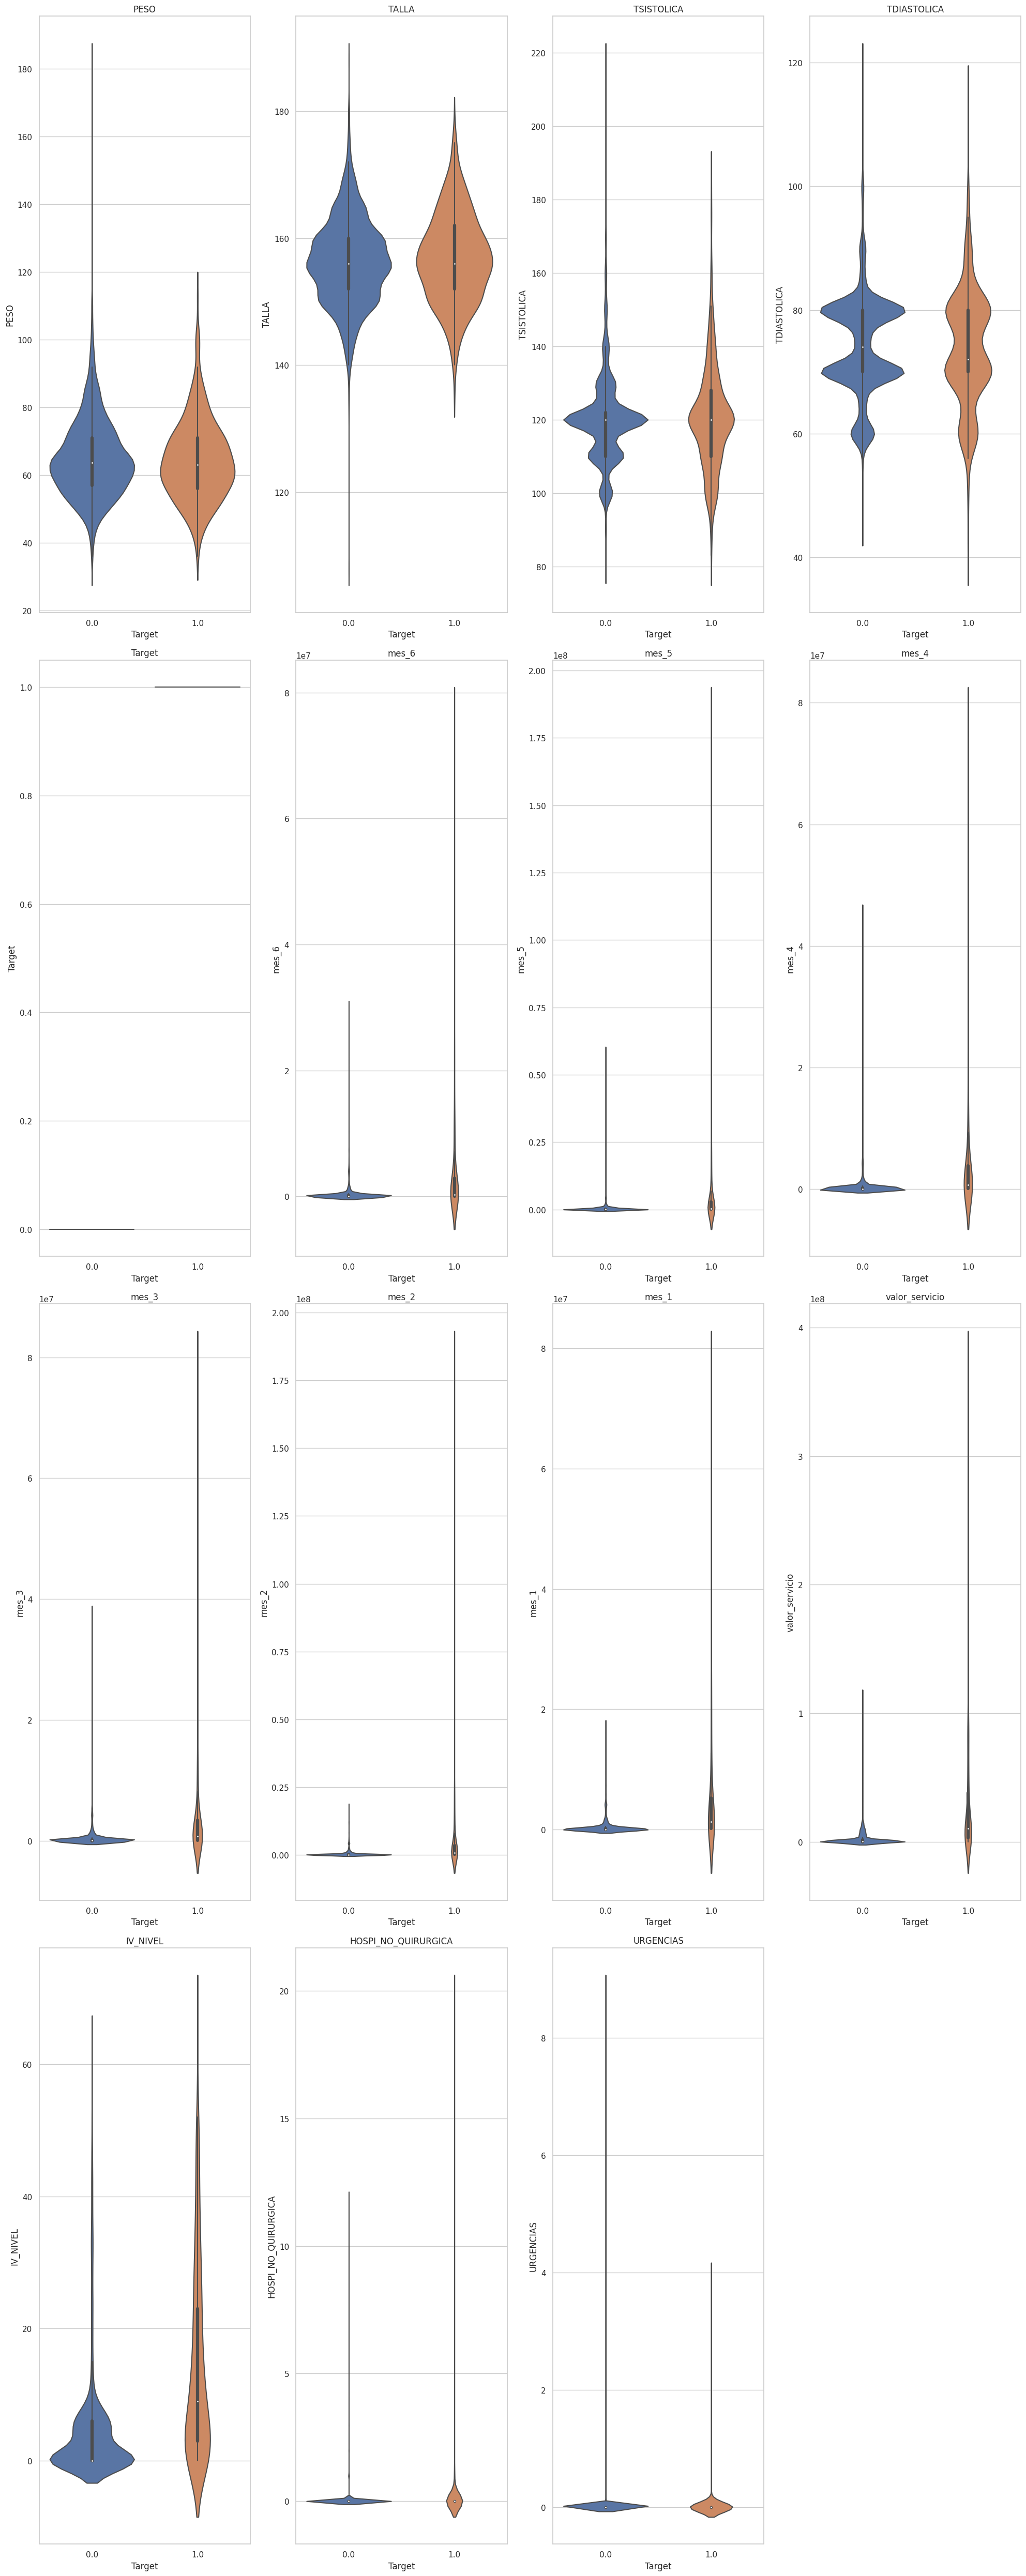

In [ ]:
fig = plt.figure(figsize=(20,50))
i=1

for var_num in df.select_dtypes(include=['int64','float64']).columns[1:16]:
    ax = fig.add_subplot(4, 4, i)
    sns.violinplot(x=df.Target, y=var_num, data=df)
    plt.title(var_num)
    i+=1
fig.tight_layout()

#### Conclusion

En este conjunto de datos (df_train.parquet). Tenemos informacion de pacientes diagnosticados con cancer de mama (mujeres), que estan entre los 40 y 80 años. Estos pacientes. con un (1) riesgo de cancer diferente a mama. La presion esta en los siguientes rangos: sistolica 120-140 y diastolica 70-90 , los antecendentes dicen que los los uqe si tienen antecedentes familiares solo el 8% tambien tiene cancer de mama , el 20% tiene otro tipo de cancer . en promedio estan en un peso de 70Kg y una estatura promedio de 155cm